In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0032.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0026.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0040.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0056.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0009.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0011.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0018.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0005.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0051.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0014.npy
/kaggle/input/datasets/jorgeoc

In [2]:
# =========================
# CELDA 1: Dataset restauración
# =========================
import os
import glob
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

ROOT = "/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2"
RDIR = os.path.join(ROOT, "restoration_dataset")

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("RDIR:", RDIR)
print("Existe RDIR:", os.path.exists(RDIR))

print("\nMuestra de archivos en restoration_dataset:")
sample_files = sorted(glob.glob(os.path.join(RDIR, "*")))[:20]
for p in sample_files:
    print(p)

Xcorr_files  = sorted(glob.glob(os.path.join(RDIR, "Xcorr_*.npy")))
Xclean_files = sorted(glob.glob(os.path.join(RDIR, "Xclean_*.npy")))
Qscore_files = sorted(glob.glob(os.path.join(RDIR, "Qscore_*.npy")))

print("\nrestoration shards Xcorr:", len(Xcorr_files))
print("restoration shards Xclean:", len(Xclean_files))
print("restoration shards Qscore:", len(Qscore_files))
print("Ejemplo Xcorr:", Xcorr_files[:3])
print("Ejemplo Xclean:", Xclean_files[:3])
print("Ejemplo Qscore:", Qscore_files[:3])

if len(Xcorr_files) == 0 or len(Xclean_files) == 0 or len(Qscore_files) == 0:
    raise FileNotFoundError(
        f"No se encontraron shards de restoration en {RDIR}. "
        f"Revisa la muestra de archivos impresa arriba."
    )

# prueba rápida
xc0 = np.load(Xcorr_files[0], mmap_mode="r")
xy0 = np.load(Xclean_files[0], mmap_mode="r")
qs0 = np.load(Qscore_files[0], mmap_mode="r")

print("\nxc0 shape:", xc0.shape, xc0.dtype)
print("xy0 shape:", xy0.shape, xy0.dtype)
print("qs0 shape:", qs0.shape, qs0.dtype, "min/max:", float(qs0.min()), float(qs0.max()))

class ShardedRestorationDataset(Dataset):
    def __init__(self, Xcorr_files, Xclean_files, Qscore_files, max_per_shard=None, seed=123):
        self.samples = []
        rng = np.random.default_rng(seed)

        for xf, yf, qf in zip(Xcorr_files, Xclean_files, Qscore_files):
            X = np.load(xf, mmap_mode="r")
            n = len(X)
            idx = np.arange(n)

            if max_per_shard is not None and n > max_per_shard:
                idx = rng.choice(idx, size=max_per_shard, replace=False)

            for i in idx:
                self.samples.append((xf, yf, qf, int(i)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        xf, yf, qf, i = self.samples[idx]
        Xc = np.load(xf, mmap_mode="r")
        Xy = np.load(yf, mmap_mode="r")
        Qs = np.load(qf, mmap_mode="r")

        xcorr = torch.tensor(Xc[i], dtype=torch.float32)
        xclean = torch.tensor(Xy[i], dtype=torch.float32)
        qscore = torch.tensor([Qs[i]], dtype=torch.float32)
        return xcorr, xclean, qscore

def split_files(files, frac_val=0.15, seed=123):
    idx = np.arange(len(files))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    n_val = max(1, int(len(files) * frac_val))
    return idx[n_val:], idx[:n_val]

def mse_np(a, b):
    return float(np.mean((a - b) ** 2))

def mae_np(a, b):
    return float(np.mean(np.abs(a - b)))

def snr_db(clean, noisy):
    clean = np.asarray(clean)
    noisy = np.asarray(noisy)
    noise = noisy - clean
    ps = np.mean(clean**2) + 1e-8
    pn = np.mean(noise**2) + 1e-8
    return 10 * np.log10(ps / pn)

def corrcoef_1d(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

RDIR: /kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset
Existe RDIR: True

Muestra de archivos en restoration_dataset:
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Qscore_0000.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Qscore_0001.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Qscore_0002.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Qscore_0003.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Qscore_0004.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Qscore_0005.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Qscore_0006.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/

In [3]:
# =========================
# CELDA 2: Modelo restaurador
# =========================
class ConvAE1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 5, stride=2, padding=2),  # 400 -> 200
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, 5, stride=2, padding=2), # 200 -> 100
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, 5, stride=2, padding=2), # 100 -> 50
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv1d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1), # 50 -> 100
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1), # 100 -> 200
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, 4, stride=2, padding=1),  # 200 -> 400
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.bottleneck(z)
        y = self.decoder(z)
        return y

In [4]:
# =========================
# CELDA 3: Entrenamiento
# =========================

idx_tr, idx_val = split_files(Xcorr_files, frac_val=0.15, seed=SEED)

train_ds = ShardedRestorationDataset(
    [Xcorr_files[i] for i in idx_tr],
    [Xclean_files[i] for i in idx_tr],
    [Qscore_files[i] for i in idx_tr],
    max_per_shard=4000,
    seed=1
)

val_ds = ShardedRestorationDataset(
    [Xcorr_files[i] for i in idx_val],
    [Xclean_files[i] for i in idx_val],
    [Qscore_files[i] for i in idx_val],
    max_per_shard=4000,
    seed=2
)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = ConvAE1D().to(device)

l1 = nn.L1Loss()
mse = nn.MSELoss()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

def composite_loss(yhat, y):
    return 0.7 * l1(yhat, y) + 0.3 * mse(yhat, y)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    losses = []
    maes_before, maes_after = [], []
    mses_before, mses_after = [], []
    snr_before, snr_after = [], []
    corr_before, corr_after = [], []

    examples = []

    for xcorr, xclean, qscore in loader:
        xcorr = xcorr.to(device)
        xclean = xclean.to(device)

        xhat = model(xcorr)
        loss = composite_loss(xhat, xclean)
        losses.append(loss.item() * xcorr.size(0))

        xc = xclean.cpu().numpy()
        xn = xcorr.cpu().numpy()
        xr = xhat.cpu().numpy()

        for i in range(len(xc)):
            clean = xc[i,0]
            noisy = xn[i,0]
            rest  = xr[i,0]

            maes_before.append(mae_np(clean, noisy))
            maes_after.append(mae_np(clean, rest))
            mses_before.append(mse_np(clean, noisy))
            mses_after.append(mse_np(clean, rest))
            snr_before.append(snr_db(clean, noisy))
            snr_after.append(snr_db(clean, rest))
            corr_before.append(corrcoef_1d(clean, noisy))
            corr_after.append(corrcoef_1d(clean, rest))

        if len(examples) < 5:
            examples.append((xn[0,0], xr[0,0], xc[0,0]))

    mets = {
        "loss": np.sum(losses) / max(len(maes_before), 1),
        "mae_before": float(np.mean(maes_before)),
        "mae_after": float(np.mean(maes_after)),
        "mse_before": float(np.mean(mses_before)),
        "mse_after": float(np.mean(mses_after)),
        "snr_before": float(np.mean(snr_before)),
        "snr_after": float(np.mean(snr_after)),
        "corr_before": float(np.mean(corr_before)),
        "corr_after": float(np.mean(corr_after)),
        "delta_mae": float(np.mean(maes_before) - np.mean(maes_after)),
        "delta_snr": float(np.mean(snr_after) - np.mean(snr_before)),
    }
    return mets, examples

history = {
    "train_loss": [], "val_loss": [],
    "mae_before": [], "mae_after": [],
    "snr_before": [], "snr_after": [],
    "corr_before": [], "corr_after": [],
}

best_state = None
best_score = -1e9
patience = 5
bad_epochs = 0
EPOCHS = 30

for ep in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    train_loss_sum, n_seen = 0.0, 0

    for xcorr, xclean, qscore in train_loader:
        xcorr = xcorr.to(device)
        xclean = xclean.to(device)

        opt.zero_grad()
        xhat = model(xcorr)
        loss = composite_loss(xhat, xclean)
        loss.backward()
        opt.step()

        train_loss_sum += loss.item() * xcorr.size(0)
        n_seen += xcorr.size(0)

    train_loss = train_loss_sum / max(n_seen, 1)
    val_mets, examples = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_mets["loss"])
    history["mae_before"].append(val_mets["mae_before"])
    history["mae_after"].append(val_mets["mae_after"])
    history["snr_before"].append(val_mets["snr_before"])
    history["snr_after"].append(val_mets["snr_after"])
    history["corr_before"].append(val_mets["corr_before"])
    history["corr_after"].append(val_mets["corr_after"])

    score = val_mets["delta_snr"] + val_mets["delta_mae"] + (val_mets["corr_after"] - val_mets["corr_before"])

    print(
        f"Epoch {ep:02d} | train_loss={train_loss:.4f} | val_loss={val_mets['loss']:.4f} | "
        f"MAE {val_mets['mae_before']:.4f}->{val_mets['mae_after']:.4f} | "
        f"SNR {val_mets['snr_before']:.2f}->{val_mets['snr_after']:.2f} | "
        f"Corr {val_mets['corr_before']:.4f}->{val_mets['corr_after']:.4f} | "
        f"time={time.time()-t0:.1f}s"
    )

    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
torch.save(model.state_dict(), "/kaggle/working/restorer_best.pt")
print("Guardado: /kaggle/working/restorer_best.pt")

device: cuda
Epoch 01 | train_loss=0.3933 | val_loss=0.2329 | MAE 0.2940->0.2559 | SNR 15.24->9.14 | Corr 0.8957->0.9242 | time=784.9s
Epoch 02 | train_loss=0.2980 | val_loss=0.2253 | MAE 0.2940->0.2484 | SNR 15.24->9.34 | Corr 0.8957->0.9271 | time=670.7s
Epoch 03 | train_loss=0.2741 | val_loss=0.2157 | MAE 0.2940->0.2399 | SNR 15.24->9.67 | Corr 0.8957->0.9327 | time=723.0s
Epoch 04 | train_loss=0.2598 | val_loss=0.2022 | MAE 0.2940->0.2253 | SNR 15.24->10.11 | Corr 0.8957->0.9339 | time=971.3s
Epoch 05 | train_loss=0.2565 | val_loss=0.1951 | MAE 0.2940->0.2178 | SNR 15.24->10.51 | Corr 0.8957->0.9379 | time=801.1s
Epoch 06 | train_loss=0.2474 | val_loss=0.1916 | MAE 0.2940->0.2139 | SNR 15.24->10.63 | Corr 0.8957->0.9384 | time=699.1s
Epoch 07 | train_loss=0.2432 | val_loss=0.1892 | MAE 0.2940->0.2117 | SNR 15.24->10.76 | Corr 0.8957->0.9394 | time=816.8s
Epoch 08 | train_loss=0.2394 | val_loss=0.1928 | MAE 0.2940->0.2161 | SNR 15.24->10.53 | Corr 0.8957->0.9389 | time=751.4s
Epoch 

Métricas finales restaurador: {'loss': np.float64(0.17545739686489106), 'mae_before': 0.2939757733436694, 'mae_after': 0.19893756005063187, 'mse_before': 0.25462755824272626, 'mse_after': 0.12067037081567833, 'snr_before': 15.240642547607422, 'snr_after': 11.430582046508789, 'corr_before': 0.8956510185584561, 'corr_after': 0.9449816180753171, 'delta_mae': 0.09503821329303755, 'delta_snr': -3.810060501098633}


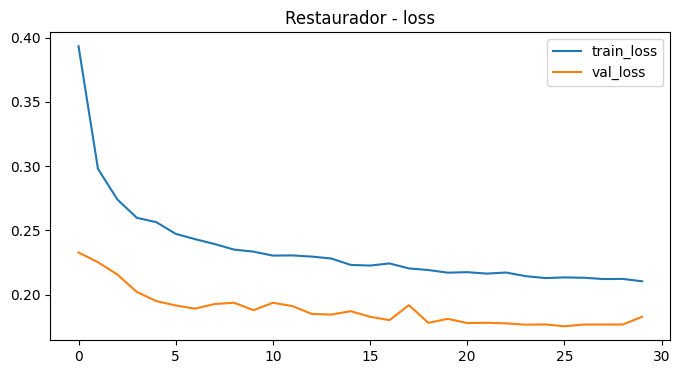

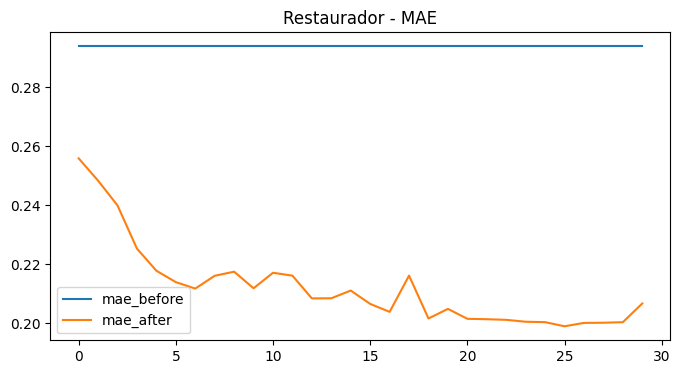

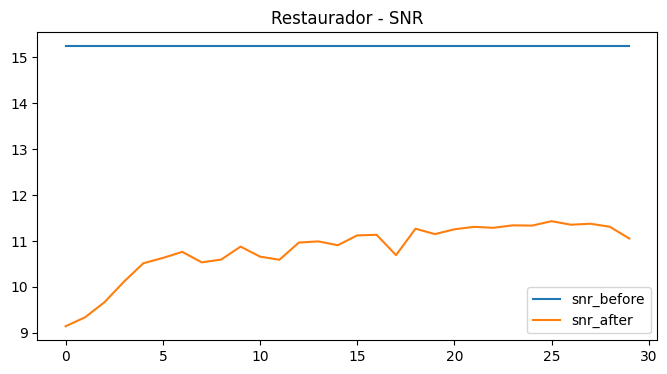

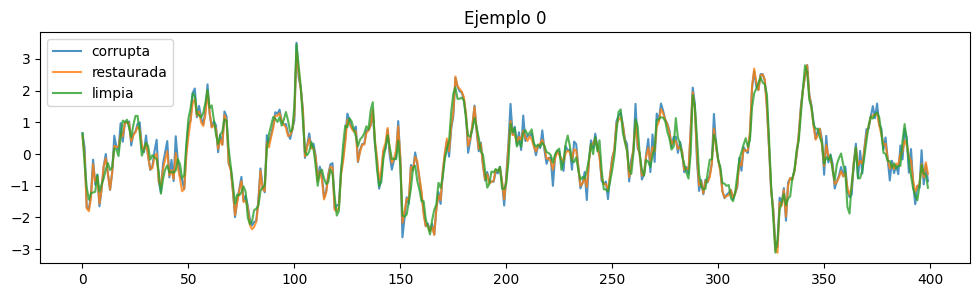

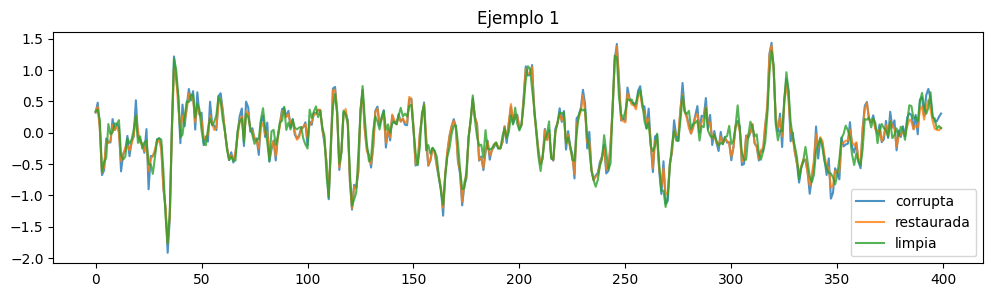

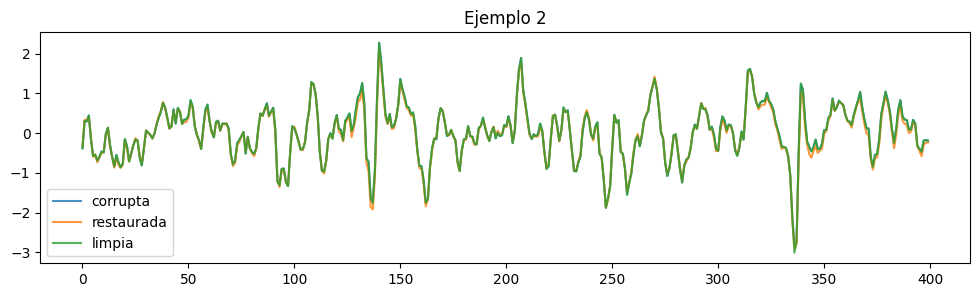

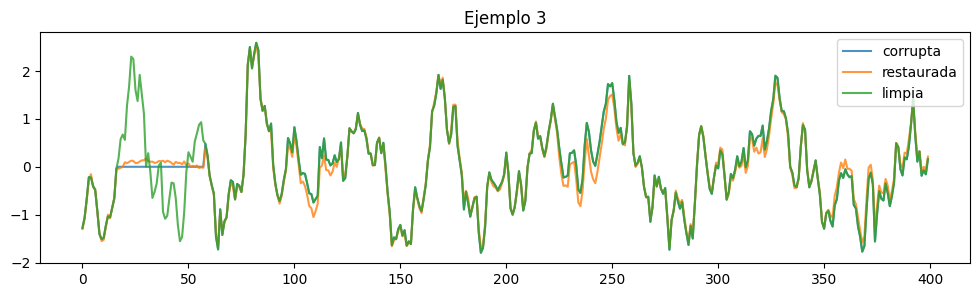

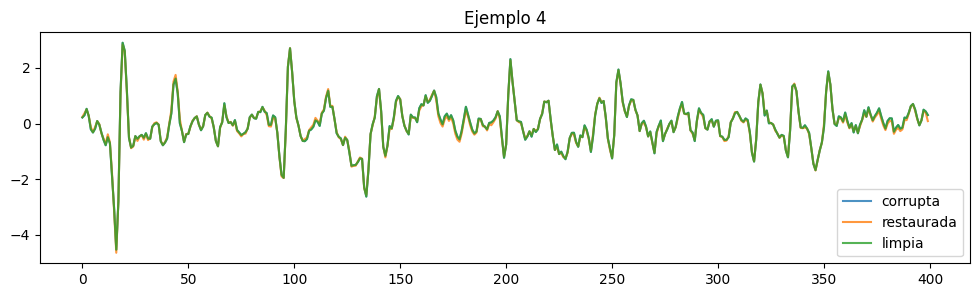

In [5]:
# =========================
# CELDA 4: Gráficas restauración
# =========================
val_mets, examples = evaluate(val_loader)
print("Métricas finales restaurador:", val_mets)

plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Restaurador - loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["mae_before"], label="mae_before")
plt.plot(history["mae_after"], label="mae_after")
plt.title("Restaurador - MAE")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["snr_before"], label="snr_before")
plt.plot(history["snr_after"], label="snr_after")
plt.title("Restaurador - SNR")
plt.legend()
plt.show()

for i, (xn, xr, xc) in enumerate(examples):
    plt.figure(figsize=(12,3))
    plt.plot(xn, label="corrupta", alpha=0.8)
    plt.plot(xr, label="restaurada", alpha=0.8)
    plt.plot(xc, label="limpia", alpha=0.8)
    plt.title(f"Ejemplo {i}")
    plt.legend()
    plt.show()